<a href="https://colab.research.google.com/github/Bagas-Meriko-newbie/Pengolahan-Citra-Digital/blob/main/Transformasi%20Geometri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 SCRIPT TRANSFORMASI CITRA
📁 Silakan upload gambar...


Saving upb to upb

✅ Gambar 'upb' berhasil diupload!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


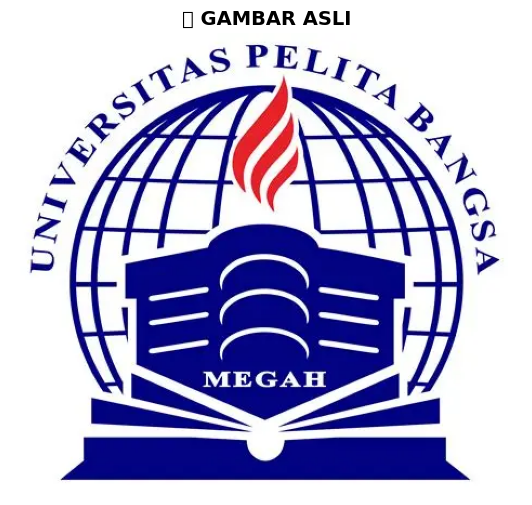


🔄 1. TRANSLASI CITRA
   Geser: +50 piksel kanan, +30 piksel bawah


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


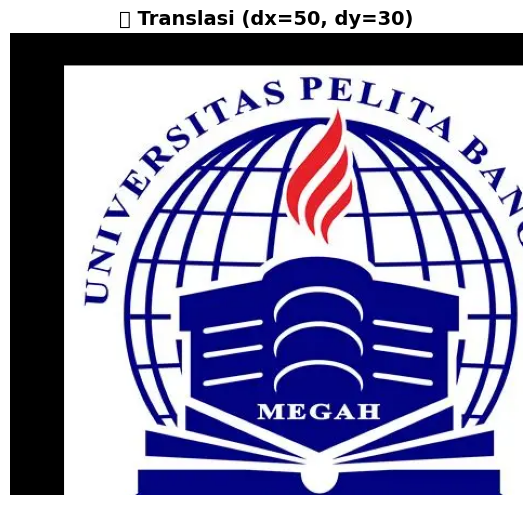


🔄 2. ROTASI CITRA


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


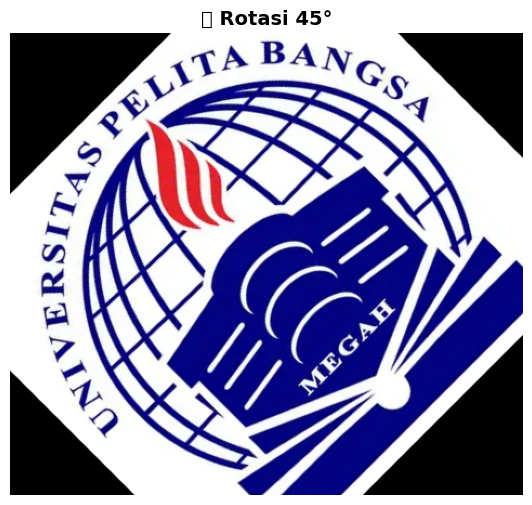

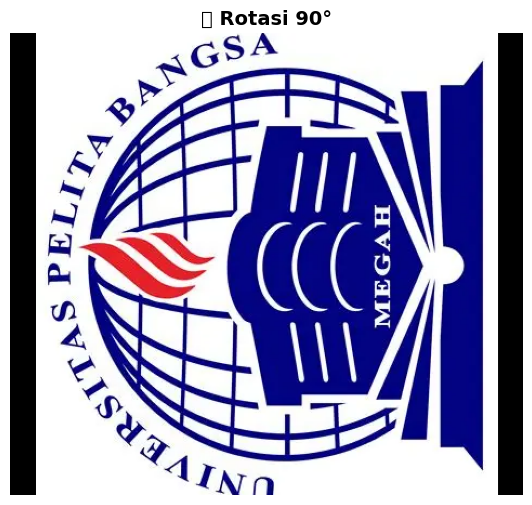

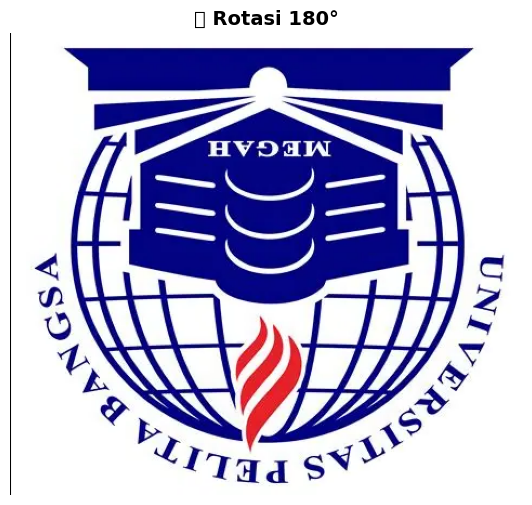


🔄 3. SCALING CITRA


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


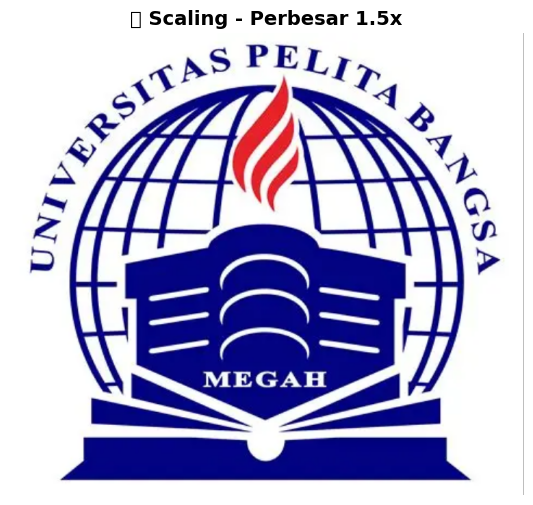

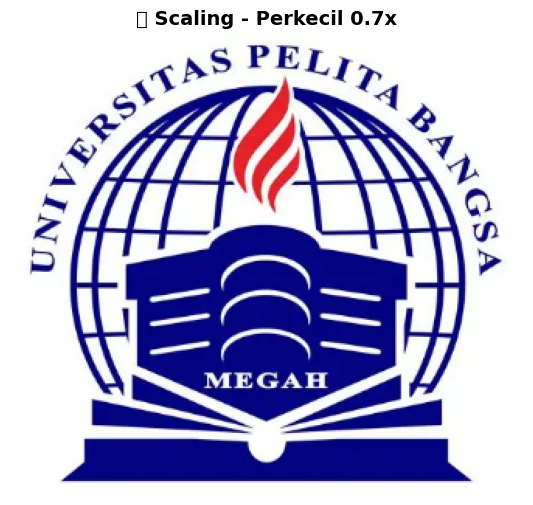

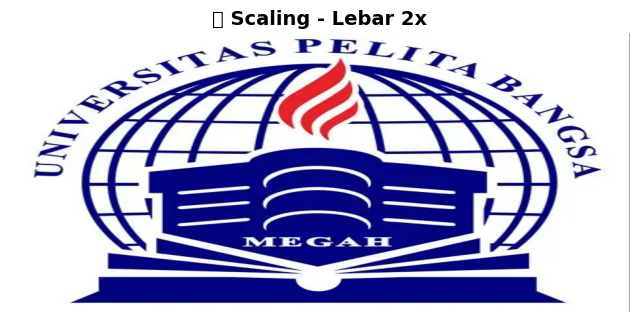


🔄 4. FLIPPING CITRA


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


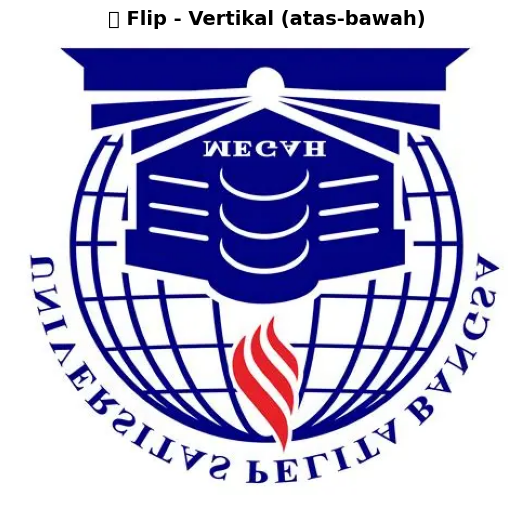

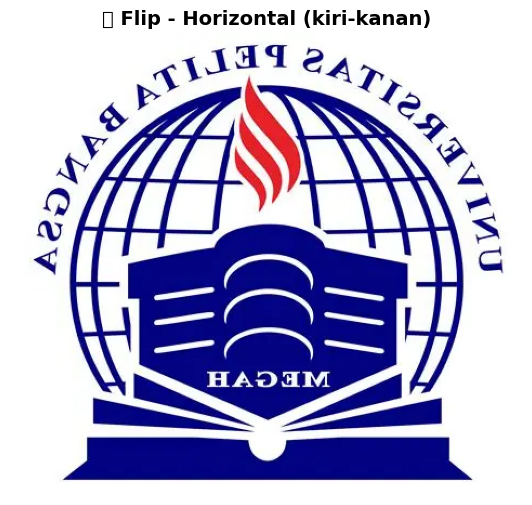

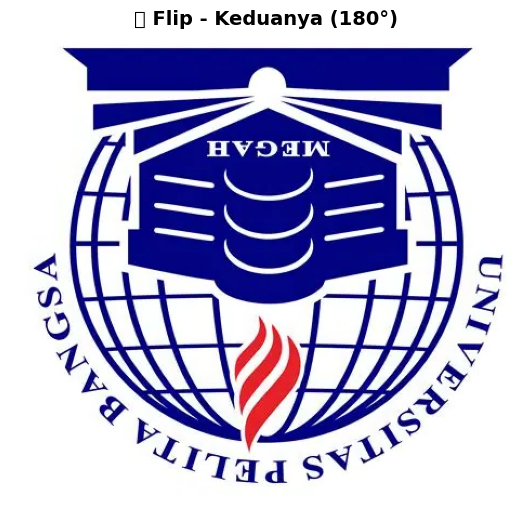


🎉 SEMUA TRANSFORMASI SELESAI!

💡 Ingin coba transformasi custom?
Jalankan sel berikut:
custom_transform()


In [ ]:
# ===============================================
# SCRIPT TRANSFORMASI CITRA - GOOGLE COLAB
# ===============================================
# Fitur: Translasi, Rotasi, Scaling, Flipping
# Library: OpenCV, Matplotlib, NumPy
# ===============================================

# Install library jika belum ada (biasanya sudah ada di Colab)
!pip install opencv-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import io

# ===============================================
# FUNGSI UPLOAD GAMBAR
# ===============================================
def upload_image():
    print("📁 Silakan upload gambar...")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    image = cv2.imread(filename)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    return image, filename

# ===============================================
# FUNGSI TAMPILKAN GAMBAR
# ===============================================
def show_image(title, image):
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# ===============================================
# 1. TRANSLASI CITRA
# ===============================================
def translasi(image, dx, dy):
    """
    dx: geser horizontal (positif=kanan, negatif=kiri)
    dy: geser vertikal (positif=bawah, negatif=atas)
    """
    rows, cols = image.shape[:2]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    translated = cv2.warpAffine(image, M, (cols, rows))
    return translated

# ===============================================
# 2. ROTASI CITRA
# ===============================================
def rotasi(image, angle):
    """
    angle: sudut rotasi dalam derajat (45°, 90°, 180°)
    """
    rows, cols = image.shape[:2]
    center = (cols//2, rows//2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (cols, rows))
    return rotated

# ===============================================
# 3. SCALING CITRA
# ===============================================
def scaling(image, scale_x, scale_y):
    """
    scale_x, scale_y: faktor skala (>1=perbesar, <1=perkecil)
    """
    rows, cols = image.shape[:2]
    new_cols = int(cols * scale_x)
    new_rows = int(rows * scale_y)
    M = cv2.warpAffine(image, np.float32([[scale_x, 0, 0], [0, scale_y, 0]]), (new_cols, new_rows))
    return M

# ===============================================
# 4. FLIPPING CITRA
# ===============================================
def flipping(image, flip_code):
    """
    flip_code:
    0: vertikal (atas-bawah)
    1: horizontal (kiri-kanan)
    -1: keduanya (rotasi 180°)
    """
    flipped = cv2.flip(image, flip_code)
    return flipped

# ===============================================
# FUNGSI MAIN - DEMONSTRASI SEMUA TRANSFORMASI
# ===============================================
def main():
    # 1. UPLOAD GAMBAR
    original_image, filename = upload_image()

    print(f"\n✅ Gambar '{filename}' berhasil diupload!")
    print("="*60)

    # 2. TAMPILKAN GAMBAR ASLI
    show_image("🖼️ GAMBAR ASLI", original_image)

    # 3. TRANSLASI
    print("\n🔄 1. TRANSLASI CITRA")
    print("   Geser: +50 piksel kanan, +30 piksel bawah")
    trans_image = translasi(original_image, 50, 30)
    show_image("📍 Translasi (dx=50, dy=30)", trans_image)

    # 4. ROTASI
    print("\n🔄 2. ROTASI CITRA")
    angles = [45, 90, 180]
    for angle in angles:
        rot_image = rotasi(original_image, angle)
        show_image(f"🔄 Rotasi {angle}°", rot_image)

    # 5. SCALING
    print("\n🔄 3. SCALING CITRA")
    scales = [(1.5, 1.5), (0.7, 0.7), (2.0, 1.0)]
    scale_names = ["Perbesar 1.5x", "Perkecil 0.7x", "Lebar 2x"]

    for i, (sx, sy) in enumerate(scales):
        scale_image = scaling(original_image, sx, sy)
        show_image(f"📏 Scaling - {scale_names[i]}", scale_image)

    # 6. FLIPPING
    print("\n🔄 4. FLIPPING CITRA")
    flip_codes = [0, 1, -1]
    flip_names = ["Vertikal (atas-bawah)", "Horizontal (kiri-kanan)", "Keduanya (180°)"]

    for i, code in enumerate(flip_codes):
        flip_image = flipping(original_image, code)
        show_image(f"🔀 Flip - {flip_names[i]}", flip_image)

    print("\n🎉 SEMUA TRANSFORMASI SELESAI!")
    print("="*60)

# ===============================================
# FUNGSI CUSTOM TRANSFORMASI
# ===============================================
def custom_transform():
    """Fungsi untuk transformasi custom sesuai input user"""
    original_image, filename = upload_image()
    show_image("🖼️ GAMBAR ASLI", original_image)

    print("\n🎛️  CUSTOM TRANSFORMASI")
    print("Pilih transformasi:")
    print("1. Translasi")
    print("2. Rotasi")
    print("3. Scaling")
    print("4. Flipping")

    choice = input("\nPilih (1-4): ")

    if choice == '1':
        dx = int(input("dx (geser horizontal): "))
        dy = int(input("dy (geser vertikal): "))
        result = translasi(original_image, dx, dy)
        show_image(f"📍 Translasi (dx={dx}, dy={dy})", result)

    elif choice == '2':
        angle = int(input("Sudut rotasi (45/90/180): "))
        result = rotasi(original_image, angle)
        show_image(f"🔄 Rotasi {angle}°", result)

    elif choice == '3':
        sx = float(input("Scale X: "))
        sy = float(input("Scale Y: "))
        result = scaling(original_image, sx, sy)
        show_image(f"📏 Scaling ({sx}x, {sy}x)", result)

    elif choice == '4':
        print("0=Vertikal, 1=Horizontal, -1=Keduanya")
        code = int(input("Flip code: "))
        result = flipping(original_image, code)
        flip_names = {0:"Vertikal", 1:"Horizontal", -1:"Keduanya"}
        show_image(f"🔀 Flip - {flip_names.get(code, 'Custom')}", result)

# ===============================================
# EXECUTE PROGRAM
# ===============================================
print("🚀 SCRIPT TRANSFORMASI CITRA")
print("="*60)

# Jalankan demo lengkap
main()

print("\n" + "="*60)
print("💡 Ingin coba transformasi custom?")
print("Jalankan sel berikut:")
print("custom_transform()")